In [3]:
# Downloads (run once)
# !wget -q http://nlp.stanford.edu/data/glove.6B.300d.zip
# !unzip -q glove.6B.300d.zip -d glove

# V1: Test accuracy: 0.8774 | Test loss: 0.2897
# V2: Test accuracy: 0.8828 | Test loss: 0.2795
# V3: Test accuracy: 0.8830 | Test loss: 0.2795
# V4:

In [19]:
# Imports
import re
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb
import matplotlib.pyplot as plt

In [10]:
# Glove params (300-dim vectors)
EMBEDDING_DIM = 300
GLOVE_PATH = "glove.6B.300d.txt" # 400.000 words
VOCAB_SIZE = 400000 # Use top 400000 freq words in vocab
MAX_LEN = 800 # Mean = 233.79, Std Dev = 173.73, Max @ ~800 (+-95%)

In [6]:
# Load data
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

C:\Users\anton\PycharmProjects\AML-miniproject-ERNIE\.venv\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [11]:
# Set up vocab
word_index = imdb.get_word_index() # returns dict{word: index}
word_index = {w: (i + 3) for w, i in word_index.items()} # add 3 spots in start
word_index["<PAD>"] = 0
word_index["<START>"] = 1
word_index["<UNK>"] = 2

In [12]:
# Make sentences uniform
x_train = pad_sequences(x_train, maxlen=MAX_LEN, padding="post", truncating="post")
x_test  = pad_sequences(x_test,  maxlen=MAX_LEN, padding="post", truncating="post")
print(f"Train shape: {x_train.shape}, Test shape: {x_test.shape}")

Train shape: (25000, 800), Test shape: (25000, 800)


In [13]:
# Load Glove embedding matrix
glove = {}

with open(GLOVE_PATH, encoding="utf-8") as f:
  # Format: [char] v1 v2 ... vn
  for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype="float32")
    glove[word] = coefs

print(f"Loaded {len(glove)} GloVe vectors")

Loaded 400000 GloVe vectors


In [14]:
# Match vocab index with Glove
embeddings = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))

misses_dict = dict()

def clean_for_vocabulary(word):
    # Remove possessives at the end of words ('s or s')
    word = re.sub(r"'s$", "", word)
    word = re.sub(r"(?<=s)'$", "", word)

    # Strip wrapping quotes around the word
    word = word.strip("'")

    # Remove isolated trash characters (like \x85 ellipsis)
    word = word.replace("\x85", "")

    return word

hits, misses, skipped = 0, 0, 0
for word, i in word_index.items():
  if i >= VOCAB_SIZE:
    skipped += 1
    continue

  vec = glove.get(word)
  if vec is not None:
    embeddings[i] = vec
    hits += 1
  else:
    word_clean = clean_for_vocabulary(word)
    vec = glove.get(word_clean)
    if vec is not None:
      embeddings[i] = vec
      hits += 1
    else:
      miss_in_dict = misses_dict.get(word)
      if miss_in_dict is not None:
        misses_dict[word] = miss_in_dict + 1
      else:
        misses_dict[word] = 1
      misses += 1

print(f"Converted {hits} words ({misses} misses - {skipped} skipped)")
print(f"Resulted in embeddings matrix with shape {embeddings.shape}")

# Convert to a list before slicing to avoid KeyError
print(list(sorted(misses_dict.items(), key=lambda item: item[1], reverse=True))[:50])

Converted 72904 words (15683 misses - 0 skipped)
Resulted in embeddings matrix with shape (400000, 300)
[('tsukino', 1), ('acurately', 1), ('familiarness', 1), ('hahahah', 1), ('bravora', 1), ("tart'n'tangy", 1), ('burgade', 1), ('templarios', 1), ('zaniacs', 1), ('uality', 1), ("yomada's", 1), ('dialoge', 1), ("kazakos'", 1), ('babaganoosh', 1), ('fastforwarding', 1), ('sters', 1), ('etherything', 1), ('trelkovsky', 1), ('jaekel', 1), ('boobage', 1), ('chulak', 1), ("'porky's'", 1), ('ludicrosity', 1), ('coprophilia', 1), ('edgeways', 1), ('whoopdedoodles', 1), ('most\x85and', 1), ("beroemd'", 1), ('aargh', 1), ('labratory', 1), ('cineliterate', 1), ('fmvs', 1), ('doctresses', 1), ('counsil', 1), ('slauther', 1), ('sommerset', 1), ('interwhined', 1), ('stribor', 1), ('approporiately', 1), ('wobblyhand', 1), ('brittannica', 1), ('lanisha', 1), ('mattter', 1), ('stuntpeople', 1), ('ugghhh', 1), ("wern't", 1), ("duchonvey's", 1), ('popularism', 1), ('mindgaming', 1), ('spoilerish', 1)]


In [15]:
def build_model():
  inputs = layers.Input(shape=(MAX_LEN,))

  # Takes word indices and maps to glove vectors
  net = layers.Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    weights=[embeddings],
    trainable=False, # freeze glove (true to fine-tune)
    mask_zero=True, # <PAD> is at index 0
  )(inputs)

  # RNN wrapper which processes sequence left-to-right and right-to-left (bidirectional)
  # LSTM layer in this config allows context encoding (read up a bit more on LSTM)
  # Each word which has a 100-dim vector embedding becomes 128-dim context embedding
  net = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(net)

  # Pools the dim of the words in a sentence to 1 vector
  # The 128-dim context embedding per word is pooled such that we get the whole sentence 128-dim context embedding
  # We can then use it in a dense layer
  net = layers.GlobalMaxPooling1D()(net)

  # More hidden layers
  net = layers.Dense(64, activation="relu")(net)
  net = layers.Dropout(0.5)(net) # Dropout to prevent overfitting
  outputs = layers.Dense(1, activation="sigmoid")(net)

  return Model(inputs, outputs)

In [20]:
# Build model
model = build_model()
model.compile(
  optimizer=tf.keras.optimizers.Adam(0.001),
  loss="binary_crossentropy",
  metrics=["accuracy"],
)

C:\Users\anton\PycharmProjects\AML-miniproject-ERNIE\.venv\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'global_max_pooling1d_1' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [21]:
# Plot model
tf.keras.utils.plot_model(model)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [22]:
# Summarize model
model.summary()

 Non-trainable params: 120,000,000 (457.76 MB)

In [23]:
# Callbacks
callbacks = [
  # Allows early stop after 2 (patiente) epochs with no improvements
  tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True),
  # Reduces learning rate by 0.5 after 1 epoch with no improvements
  tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=1),
]

In [25]:
# Fit model
history = model.fit(
  x_train, y_train,
  validation_split=0.2,
  epochs=3,
  batch_size=128,
  callbacks=callbacks,
  verbose=1,
)

157/157 ━━━━━━━━━━━━━━━━━━━━ 565s 4s/step - accuracy: 0.9400 - loss: 0.1709 - val_accuracy: 0.8922 - val_loss: 0.2636 - learning_rate: 0.0010


In [26]:
# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}")


Test accuracy: 0.8953 | Test loss: 0.2549


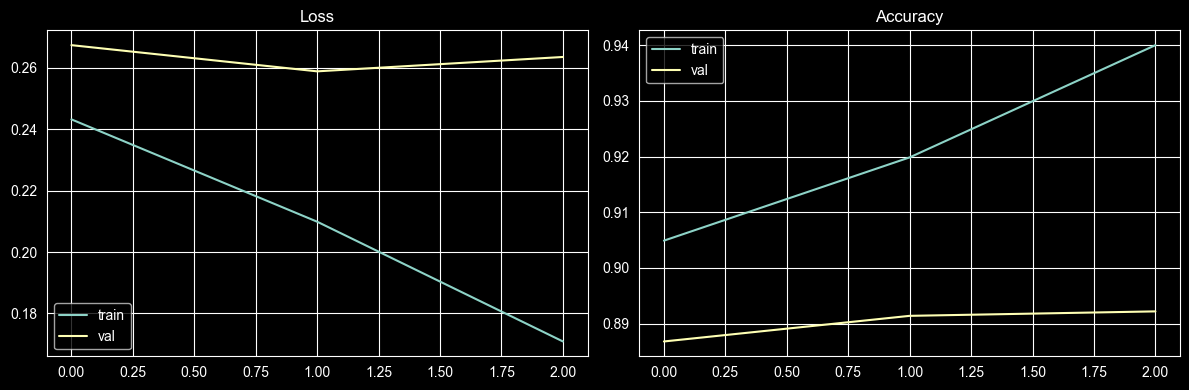

In [27]:
# Plot training
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy"); axes[1].legend()
plt.tight_layout(); plt.show()

In [28]:
# Save model
model.save('glove_model.keras')

In [29]:
# Predict util functions + Load model (RUN COLAB FROM HERE AFTER MODEL IS BUILT)
model = tf.keras.models.load_model('glove_model.keras')

def find_correct_index(word: str):
  ind = word_index.get(word)
  if ind is not None:
    return ind
  else:
    return word_index.get(clean_for_vocabulary(word), 2) # 2 = <UNK>

def encode_review(text: str, word_index, max_len=MAX_LEN):
  tokens = text.lower().split()
  ids = [find_correct_index(t) for t in tokens]
  ids = [i if i < VOCAB_SIZE else 2 for i in ids]
  return pad_sequences([ids], maxlen=max_len, padding="post", truncating="post")

def predict(sample):
  prob = model.predict(encode_review(sample, word_index))[0, 0]
  print(f"\nReview: {sample!r}\nP(positive) = {prob:.3f}")

In [30]:
predict("this movie was absolutely fantastic the acting was brilliant") # Predicts good ✅
predict("not the worst movie i've ever seen") # Predicts as bad although it is okay ❌
predict("not not not not not not the best movie i've ever seen") # Predicts as good although it isn't great ❌
predict("not the best movie i've ever seen") # Predicts as good although it isn't great ❌
predict("the best movie i've ever seen") # Predicts as good although it isn't great ❌
predict("the movie was decent but i would mind watching it again") # Predicts okay but more good than bad ⚠️

predict("The movie was not bad") # Predicts
predict("I didn't hate it") # Predicts
predict("It could have been better") # Predicts
predict("It was not not badbad") # Predicts
predict("It done be the bestest") # Predicts
predict("T’wos nat gud") # Predicts
predict("Some very long ... great") # Predicts


Review: 'Some very long ... great'
P(positive) = 0.900
